In [ ]:
import biom
import pandas as pd
import glob
from biom import Table, example_table
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns 
plt.style.use('fast')

ModuleNotFoundError: No module named 'dokdo'

In [3]:
# Read V3V4 and V4 metadata csvs
v3v4 = pd.read_csv('v3-v4-5.txt', delimiter = '\t')
v4 = pd.read_csv('v4-5.txt', delimiter = '\t')

In [ ]:
# Read all metadata csv
df = pd.read_csv('Full-5.tsv', delimiter = '\t')
df['Class'] = df['Class'].apply(lambda x: 'Mammalia' if x == 'Mammilia' or x == 'Mamallia' else x)
df['Phylum'] = df['Phylum'].apply(lambda x: 'Arthropoda' if x == 'Anthropoda' else x)
df

In [8]:
# Plot global host distribution
import pandas as pd
from shapely.geometry import Point
import geopandas as gpd
from geopandas import GeoDataFrame
import plotly.express as px
df['Class'] = df['Class'].apply(lambda x: 'Mammalia' if x == 'Mammilia' or x == 'Mamallia' else x)
df['Wind'] = df['Wind'].round(2)
geometry = [Point(xy) for xy in zip(df['Longitude'], df['Latitude'])]
geo_df = GeoDataFrame(df, geometry=geometry)  
fig = px.scatter_geo(geo_df,
                    lat=geo_df.geometry.y,
                    lon=geo_df.geometry.x,
                    color = 'Class',
                    title='Geographic Distribution of Host Classes Sampled',
                    hover_name = 'Study',
                    hover_data = ['Elevation', 'Host', 'Temp_Mean', 'Wind'])
fig.update_traces(textposition='top center', textfont_size = 8)
fig.update_layout(
    width=1200,   # Set the width of the figure (in pixels)
    height=800,
    title={'font':dict(size=30),'x':0.45,'y':0.85},
    legend=dict(
        title='Class',
        title_font=dict(size=22), 
        font=dict(size=18),
        y=0.5,
        itemsizing='constant'        
    )
)

fig.show()

In [ ]:
# Import Faith's PD table
faith_table = pd.read_csv('faith.tsv', delimiter='\t').drop(index=0)
faith_table['Class'] = faith_table['Class'].apply(lambda x: 'Mammalia' if x == 'Mammilia' or x == 'Mamallia' else x)
faith_table['faith_pd'] = pd.to_numeric(faith_table['faith_pd'])
faith_table.head()

In [ ]:
# Set plot palette and order
pal1 = sns.color_palette('deep')[1:8]
pal2 = sns.color_palette('Set3', 12)
ord = faith_table.groupby('Phylum')['Class'].unique().tolist()
order = []
for sublist in ord:
    order.extend(sublist)

/tmp/ipykernel_1086/762869593.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_1086/762869593.py:3: UserWarning:

The palette list has more values (7) than needed (6), which may not be intended.

/tmp/ipykernel_1086/762869593.py:6: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_1086/762869593.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_1086/762869593.py:10: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



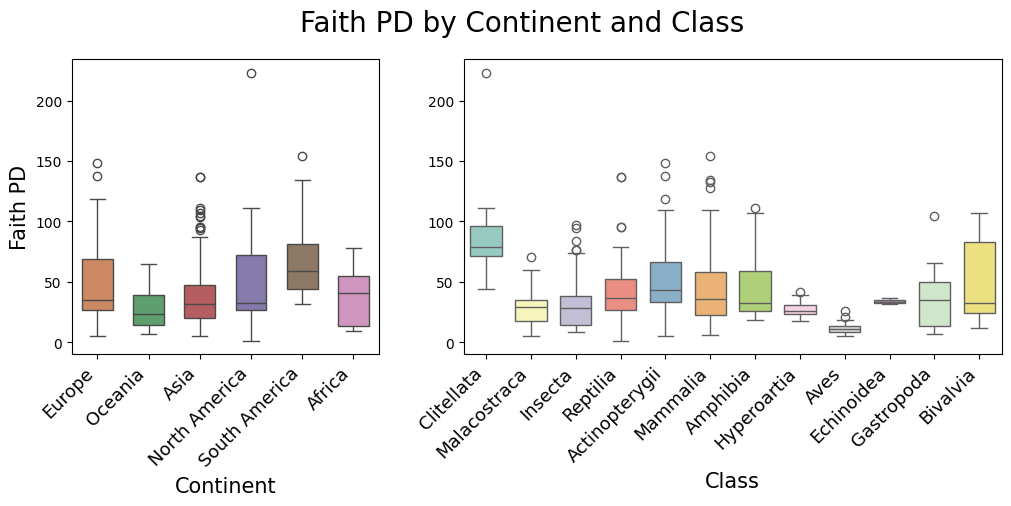

In [ ]:
# Plot Faith's PD by Continent and Class
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5), gridspec_kw={'width_ratios': [2, 3.5]})
plt.suptitle('Faith PD by Continent and Class', fontsize = 20)
sns.boxplot(data = faith_table, x = 'Continent',y='faith_pd', ax=ax1, width=0.6, palette=pal1)
ax1.set_ylabel('Faith PD', fontsize = 15)
ax1.set_xlabel('Continent', fontsize = 15)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=13)
sns.boxplot(data = faith_table, x = 'Class',y='faith_pd', ax=ax2, width = 0.7, palette=pal2, order = order)
ax2.set_ylabel(None)
ax2.set_xlabel('Class', fontsize = 15)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=13)
plt.subplots_adjust(bottom=0.29)
plt.show()

In [ ]:
# Import Shannon Entropy Table
shannon_table = pd.read_csv('shannon.tsv', delimiter='\t').drop(index=0)
shannon_table['shannon_entropy'] = pd.to_numeric(shannon_table['shannon_entropy'])
shannon_table.head()

,id,Study,Link,Host,Phylum,Class,Order,Family,Genus,Species,Diet,16S 515F-806R,Land_Water_Air,AquaStat_Link,Climate_Notes,GMTOL_Notes,16S515F-806R,initials,Continent,shannon_entropy
1,baldo1,Baldo_et_al_2018,https://academic.oup.com/femsec/article/94/2/f...,Lilford's Wall Lizard,Chordata,Reptilia,Squamata,Lacertidae,Podarcis,Podarcis_Lilfordi,Omnivore,V3-V4,Land,https://aquastat.fao.org/climate-information-t...,NaN,NaN,V3-V4,AK,Europe,7.242786
2,baldo2,Baldo_et_al_2018,https://academic.oup.com/femsec/article/94/2/f...,Lilford's Wall Lizard,Chordata,Reptilia,Squamata,Lacertidae,Podarcis,Podarcis_Lilfordi,Omnivore,V3-V4,Land,https://aquastat.fao.org/climate-information-t...,NaN,NaN,V3-V4,AK,Europe,7.052703
3,baldo3,Baldo_et_al_2018,https://academic.oup.com/femsec/article/94/2/f...,Lilford's Wall Lizard,Chordata,Reptilia,Squamata,Lacertidae,Podarcis,Podarcis_Lilfordi,Omnivore,V3-V4,Land,https://aquastat.fao.org/climate-information-t...,NaN,NaN,V3-V4,AK,Europe,7.427209
4,baldo4,Baldo_et_al_2018,https://academic.oup.com/femsec/article/94/2/f...,Lilford's Wall Lizard,Chordata,Reptilia,Squamata,Lacertidae,Podarcis,Podarcis_Lilfordi,Omnivore,V3-V4,Land,https://aquastat.fao.org/climate-information-t...,NaN,NaN,V3-V4,AK,Europe,7.070179
5,baldo5,Baldo_et_al_2018,https://academic.oup.com/femsec/article/94/2/f...,Lilford's Wall Lizard,Chordata,Reptilia,Squamata,Lacertidae,Podarcis,Podarcis_Lilfordi,Omnivore,V3-V4,Land,https://aquastat.fao.org/climate-information-t...,NaN,NaN,V3-V4,AK,Europe,8.095616


/tmp/ipykernel_1086/1608305238.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_1086/1608305238.py:3: UserWarning:

The palette list has more values (7) than needed (6), which may not be intended.

/tmp/ipykernel_1086/1608305238.py:6: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_1086/1608305238.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_1086/1608305238.py:7: UserWarning:

The palette list has more values (7) than needed (6), which may not be intended.

/tmp/ipykernel_1086/1608305238.py:10: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e.

[Text(0, 0, 'Europe'),
 Text(1, 0, 'Oceania'),
 Text(2, 0, 'Asia'),
 Text(3, 0, 'North America'),
 Text(4, 0, 'South America'),
 Text(5, 0, 'Africa')]

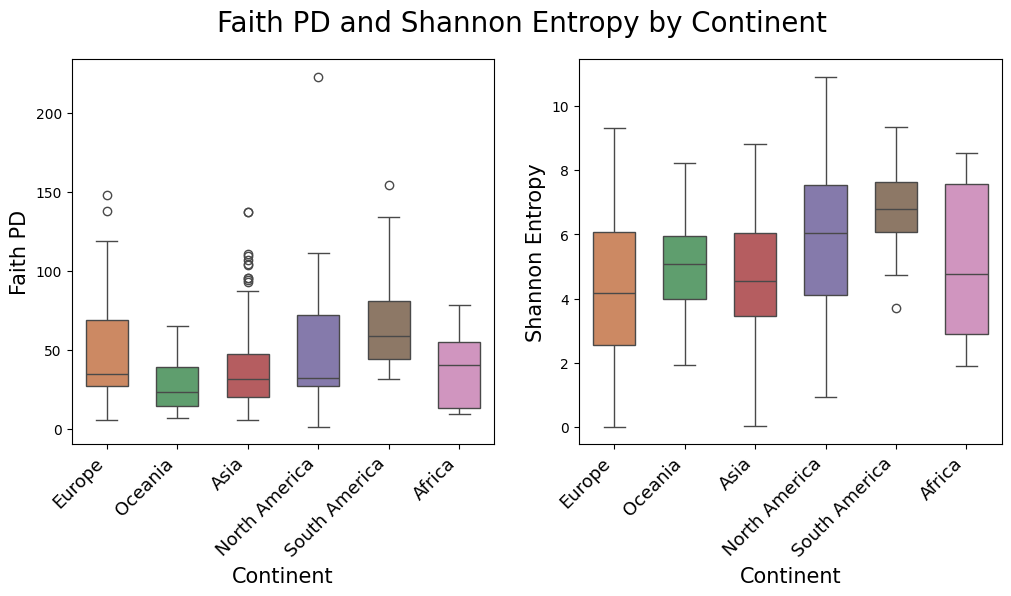

In [ ]:
# Plot Faith PD and Shannon Entropy by Continent
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
plt.suptitle('Faith PD and Shannon Entropy by Continent', fontsize = 20)
sns.boxplot(data = faith_table, x = 'Continent',y='faith_pd', ax=ax1, width=0.6, palette=pal1)
ax1.set_ylabel('Faith PD', fontsize = 15)
ax1.set_xlabel('Continent', fontsize = 15)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=13)
sns.boxplot(data = shannon_table, x = 'Continent',y='shannon_entropy', ax=ax2, width = 0.6, palette=pal1)
ax2.set_ylabel('Shannon Entropy', fontsize = 15)
ax2.set_xlabel('Continent', fontsize = 15)
ax2.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=13)

/tmp/ipykernel_1086/553828546.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_1086/553828546.py:3: UserWarning:

The palette list has more values (7) than needed (6), which may not be intended.

/tmp/ipykernel_1086/553828546.py:6: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_1086/553828546.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_1086/553828546.py:7: UserWarning:

The palette list has more values (7) than needed (6), which may not be intended.

/tmp/ipykernel_1086/553828546.py:10: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after

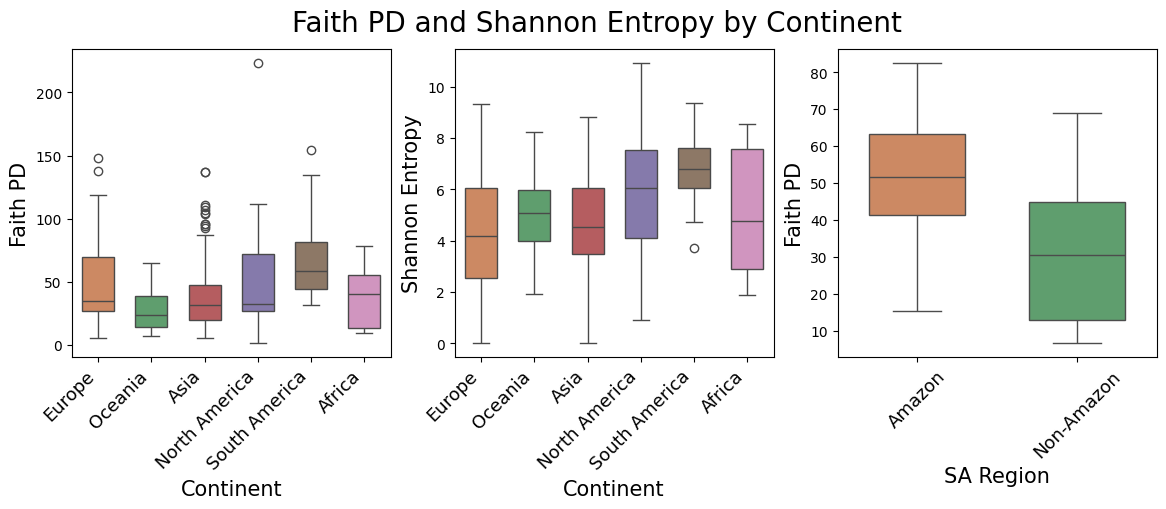

In [ ]:
# Plot Faith PD and Shannon Entropy by Continent, include Faith breakout by SA region
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(14,4))
plt.suptitle('Faith PD and Shannon Entropy by Continent', fontsize = 20)
sns.boxplot(data = faith_table, x = 'Continent',y='faith_pd', ax=ax1, width=0.6, palette=pal1)
ax1.set_ylabel('Faith PD', fontsize = 15)
ax1.set_xlabel('Continent', fontsize = 15)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=13)
sns.boxplot(data = shannon_table, x = 'Continent',y='shannon_entropy', ax=ax2, width = 0.6, palette=pal1)
ax2.set_ylabel('Shannon Entropy', fontsize = 15)
ax2.set_xlabel('Continent', fontsize = 15)
ax2.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=13)
amazon = faith_table[faith_table['Study'].isin(['McCauley_et_al_2020','Pires_et_al_2019','Sylvain_et_al_2020','Schaan_et_al_2021'])]
n_amazon = faith_table[faith_table['Study'].isin(['Rohrer_et_al_2023','Vasco_et_al_2022','Vejar_et_al_2017','Barrionueva_et_al_2022','Silva_et_al_2022'])]
sns.boxplot(data=[list(amazon['faith_pd']),list(n_amazon['faith_pd'])], ax=ax3, width = 0.6, palette=pal1[0:2])
ax3.set_xticks([0,1],['Amazon','Non-Amazon'], fontsize=13, rotation=45)
ax3.set_ylabel('Faith PD', fontsize=15)
ax3.set_xlabel('SA Region', fontsize=15)
plt.show()

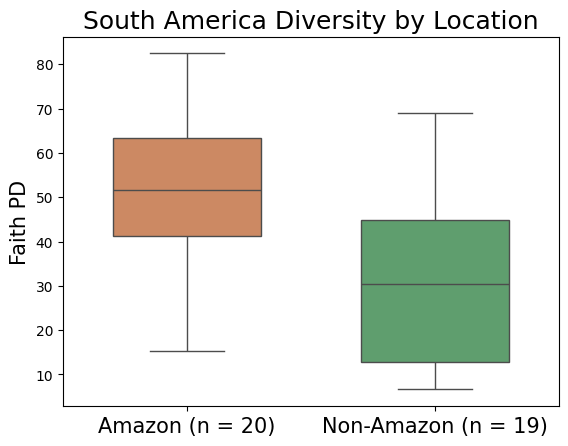

In [ ]:
# Plot Faith PD by SA Region
amazon = faith_table[faith_table['Study'].isin(['McCauley_et_al_2020','Pires_et_al_2019','Sylvain_et_al_2020','Schaan_et_al_2021'])]
n_amazon = faith_table[faith_table['Study'].isin(['Rohrer_et_al_2023','Vasco_et_al_2022','Vejar_et_al_2017','Barrionueva_et_al_2022','Silva_et_al_2022'])]
sns.boxplot(data=[list(amazon['faith_pd']),list(n_amazon['faith_pd'])], width = 0.6, palette=pal1[0:2])
plt.xticks([0,1],['Amazon (n = 20)','Non-Amazon (n = 19)'], fontsize=15)
plt.ylabel('Faith PD', fontsize=15)
plt.title('South America Diversity by Location', fontsize=18)
plt.show()

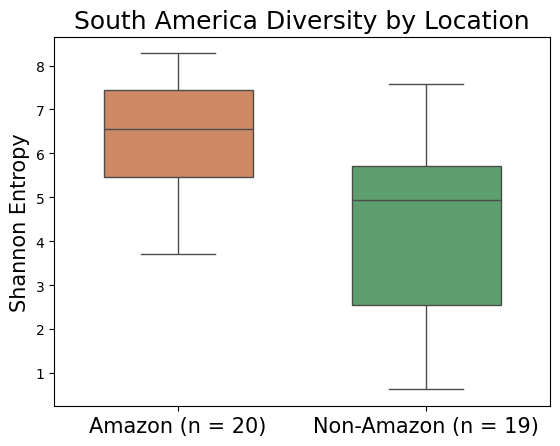

In [ ]:
# Plot Shannon Entropy by SA Region
amazon_s = shannon_table[shannon_table['Study'].isin(['McCauley_et_al_2020','Pires_et_al_2019','Sylvain_et_al_2020','Schaan_et_al_2021'])]
n_amazon_s = shannon_table[shannon_table['Study'].isin(['Rohrer_et_al_2023','Vasco_et_al_2022','Vejar_et_al_2017','Barrionueva_et_al_2022','Silva_et_al_2022'])]
sns.boxplot(data=[list(amazon_s['shannon_entropy']),list(n_amazon_s['shannon_entropy'])], width = 0.6, palette=pal1[0:2])
plt.xticks([0,1],['Amazon (n = 20)','Non-Amazon (n = 19)'], fontsize=15)
plt.ylabel('Shannon Entropy', fontsize=15)
plt.title('South America Diversity by Location', fontsize=18)
plt.show()

In [ ]:
from scipy.stats import kruskal

# Perform Kruskal-Wallis H-test by amazon region
stat, p = kruskal(amazon_s['shannon_entropy'], n_amazon_s['shannon_entropy'])
print(stat, p)

8.703947368421069 0.00317521716113176


In [ ]:
# Perform Kruskal-Wallis H-test by amazon region for Hominidae
stat, p = kruskal(amazon_s[amazon_s['Family']=='Hominidae']['shannon_entropy'], n_amazon_s[n_amazon_s['Family']=='Hominidae']['shannon_entropy'])
print(stat, p)

0.7350000000000065 0.39126727928263727


In [ ]:
# Perform Kruskal-Wallis H-test by amazon region for non-Hominidae
stat, p = kruskal(amazon_s[amazon_s['Family']!='Hominidae']['shannon_entropy'], n_amazon_s[n_amazon_s['Family']!='Hominidae']['shannon_entropy'])
print(stat, p)

6.942857142857136 0.008415458738002186


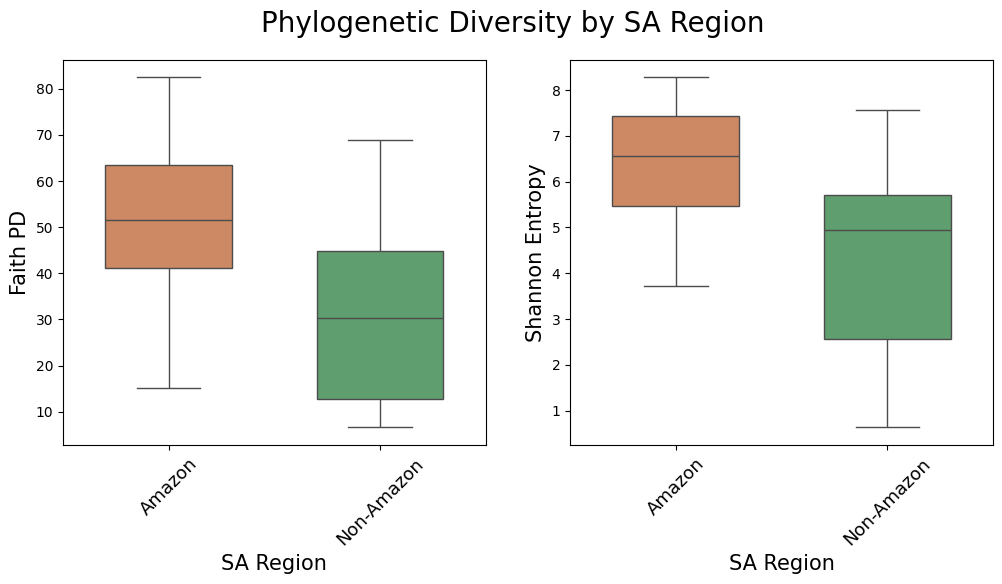

In [ ]:
# Plot Faith's PD and Shannon Entropy by SA Region
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
plt.suptitle('Phylogenetic Diversity by SA Region', fontsize = 20)
amazon = faith_table[faith_table['Study'].isin(['McCauley_et_al_2020','Pires_et_al_2019','Sylvain_et_al_2020','Schaan_et_al_2021'])]
n_amazon = faith_table[faith_table['Study'].isin(['Rohrer_et_al_2023','Vasco_et_al_2022','Vejar_et_al_2017','Barrionueva_et_al_2022','Silva_et_al_2022'])]
sns.boxplot(data=[list(amazon['faith_pd']),list(n_amazon['faith_pd'])], ax=ax1, width = 0.6, palette=pal1[0:2])
ax1.set_xticks([0,1],['Amazon','Non-Amazon'], fontsize=13, rotation=45)
ax1.set_ylabel('Faith PD', fontsize=15)
ax1.set_xlabel('SA Region', fontsize=15)
amazon_s = shannon_table[shannon_table['Study'].isin(['McCauley_et_al_2020','Pires_et_al_2019','Sylvain_et_al_2020','Schaan_et_al_2021'])]
n_amazon_s = shannon_table[shannon_table['Study'].isin(['Rohrer_et_al_2023','Vasco_et_al_2022','Vejar_et_al_2017','Barrionueva_et_al_2022','Silva_et_al_2022'])]
sns.boxplot(data=[list(amazon_s['shannon_entropy']),list(n_amazon_s['shannon_entropy'])], ax=ax2, width = 0.6, palette=pal1[0:2])
ax2.set_xticks([0,1],['Amazon','Non-Amazon'], fontsize=13, rotation=45)
ax2.set_ylabel('Shannon Entropy', fontsize=15)
ax2.set_xlabel('SA Region', fontsize=15)
plt.show()

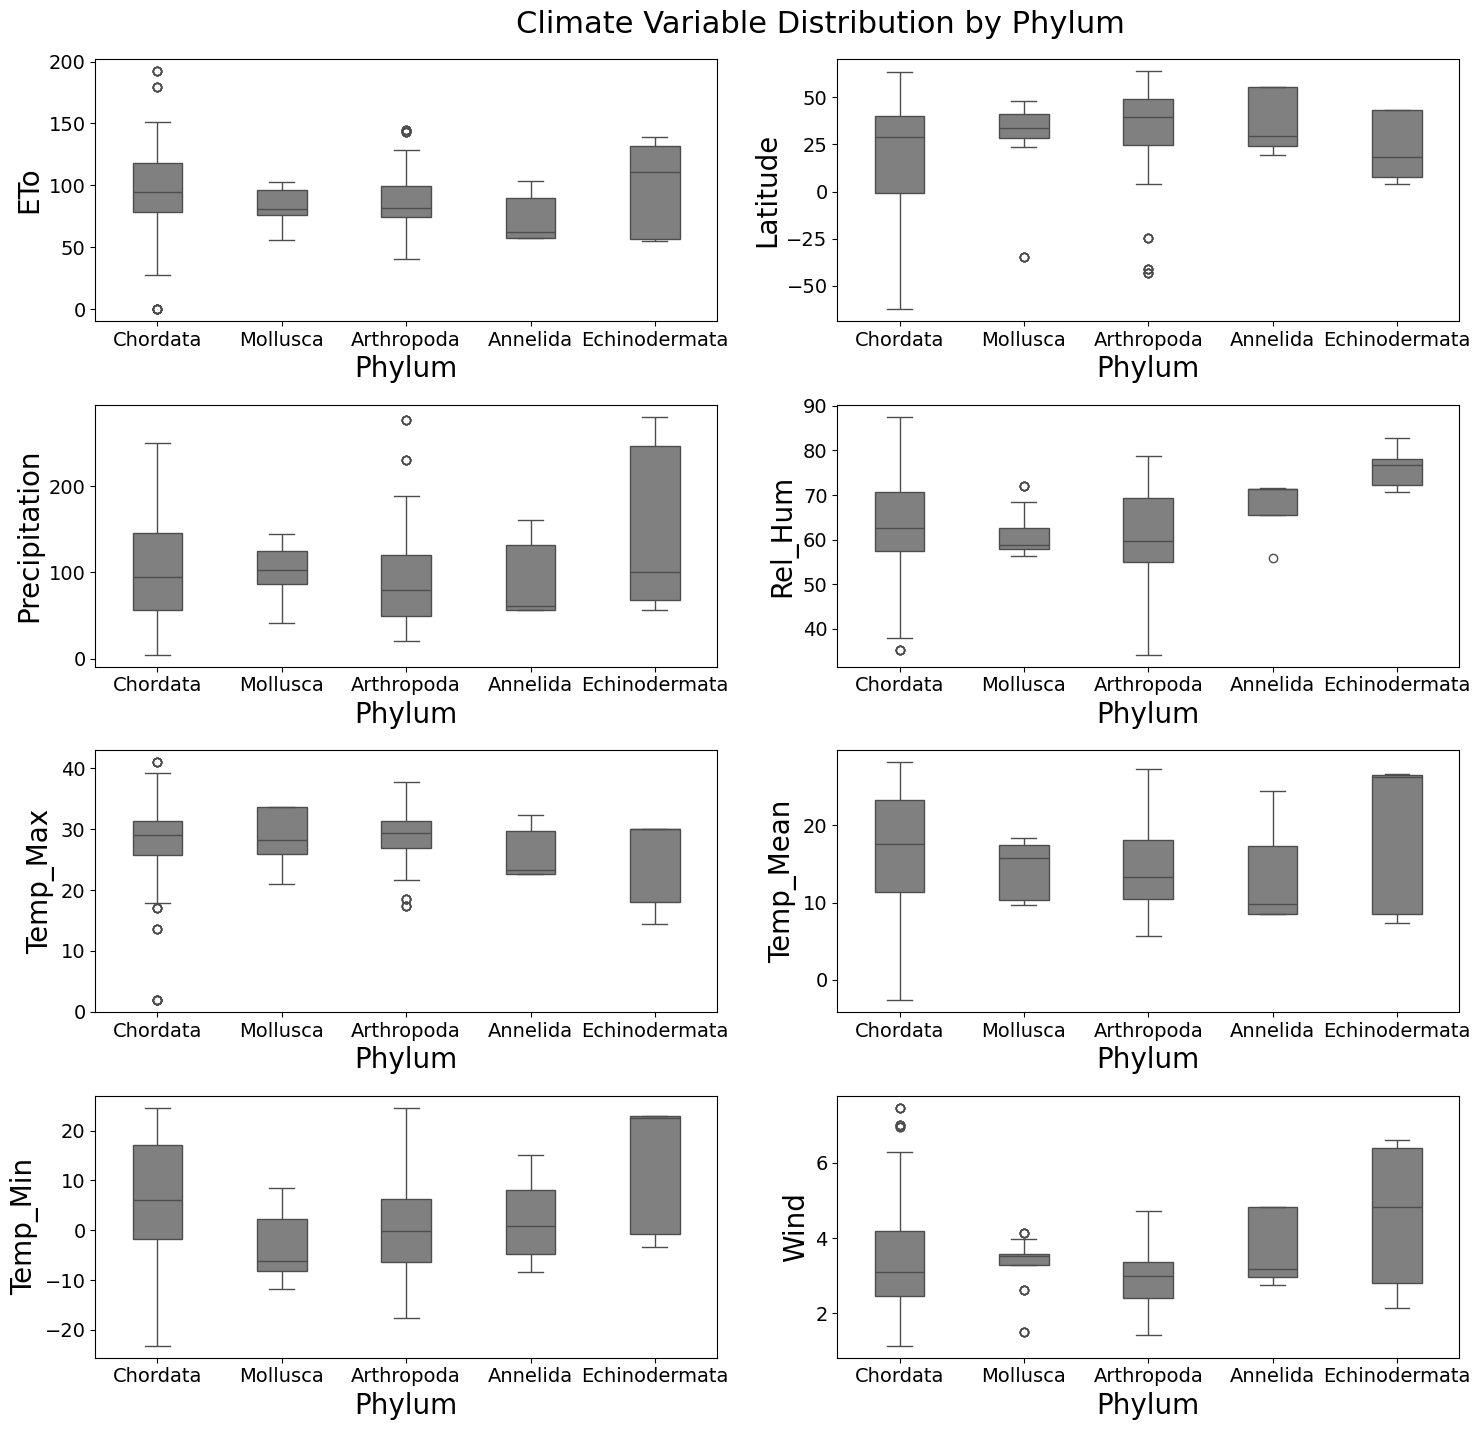

In [ ]:
# Plot climate variable distribution by phylum 
pal = sns.color_palette('deep')[0:5]
climate = ['ETo','Latitude', 'Precipitation', 'Rel_Hum','Temp_Max', 'Temp_Mean', 'Temp_Min', 'Wind']
fig, axes = plt.subplots(4, 2, figsize=(15, 15))
axes = axes.flatten()
for i, ax in enumerate(axes):
    sns.boxplot(x = 'Phylum', y = climate[i], data = df, ax=ax, color='gray', width=0.4)
    ax.set_xlabel('Phylum', fontsize=20)
    ax.set_ylabel(climate[i], fontsize=20)
    ax.tick_params(axis='y',labelsize=14)
    ax.tick_params(axis='x',labelsize=14)
plt.suptitle('Climate Variable Distribution by Phylum', x=0.55, y = 0.95, fontsize=22)
plt.tight_layout(rect=[0,0,1,0.96])